In [1]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
from scipy.stats import ttest_ind
%run ../functions/Transfer_longitude.ipynb
%run ../functions/Yearly_mean.ipynb
%run ../functions/Seasonal_means.ipynb
%run ../functions/Weighted_monthly_mean.ipynb
%run ../functions/mask_land_ocean.ipynb
%run ../functions/Moving_mean.ipynb
%run ../functions/lanczos_filter.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /knight/anaconda_aug22/envs/aug22_env/share/proj failed


## Read the data

In [2]:
diri='/zhoulab_rit/lzhuo/data/Modelling/ense_mean_diff/Med/'
filename='lead_lag.nc'
fi=xr.open_dataset(diri+filename)
r_H_Med=fi.r_H
r_V_Med=fi.r_V
r_DTCOND_Med=fi.r_DTCOND
r_QRS_Med=fi.r_QRS
r_QRL_Med=fi.r_QRL
r_DTV_Med=fi.r_DTV
p_H_Med=fi.p_H
p_V_Med=fi.p_V
p_DTCOND_Med=fi.p_DTCOND
p_QRS_Med=fi.p_QRS
p_QRL_Med=fi.p_QRL
p_DTV_Med=fi.p_DTV

In [3]:
diri='/zhoulab_rit/lzhuo/data/Modelling/ense_mean_diff/Car/'
filename='lead_lag.nc'
fi=xr.open_dataset(diri+filename)
r_H_Car=fi.r_H
r_V_Car=fi.r_V
r_DTCOND_Car=fi.r_DTCOND
r_QRS_Car=fi.r_QRS
r_QRL_Car=fi.r_QRL
r_DTV_Car=fi.r_DTV
p_H_Car=fi.p_H
p_V_Car=fi.p_V
p_DTCOND_Car=fi.p_DTCOND
p_QRS_Car=fi.p_QRS
p_QRL_Car=fi.p_QRL
p_DTV_Car=fi.p_DTV

In [4]:
diri='/zhoulab_rit/lzhuo/data/Modelling/ense_mean_diff/Ind/'
filename='lead_lag.nc'
fi=xr.open_dataset(diri+filename)
r_H_Ind=fi.r_H
r_V_Ind=fi.r_V
r_DTCOND_Ind=fi.r_DTCOND
r_QRS_Ind=fi.r_QRS
r_QRL_Ind=fi.r_QRL
r_DTV_Ind=fi.r_DTV
p_H_Ind=fi.p_H
p_V_Ind=fi.p_V
p_DTCOND_Ind=fi.p_DTCOND
p_QRS_Ind=fi.p_QRS
p_QRL_Ind=fi.p_QRL
p_DTV_Ind=fi.p_DTV

(-1.0, 1.0)

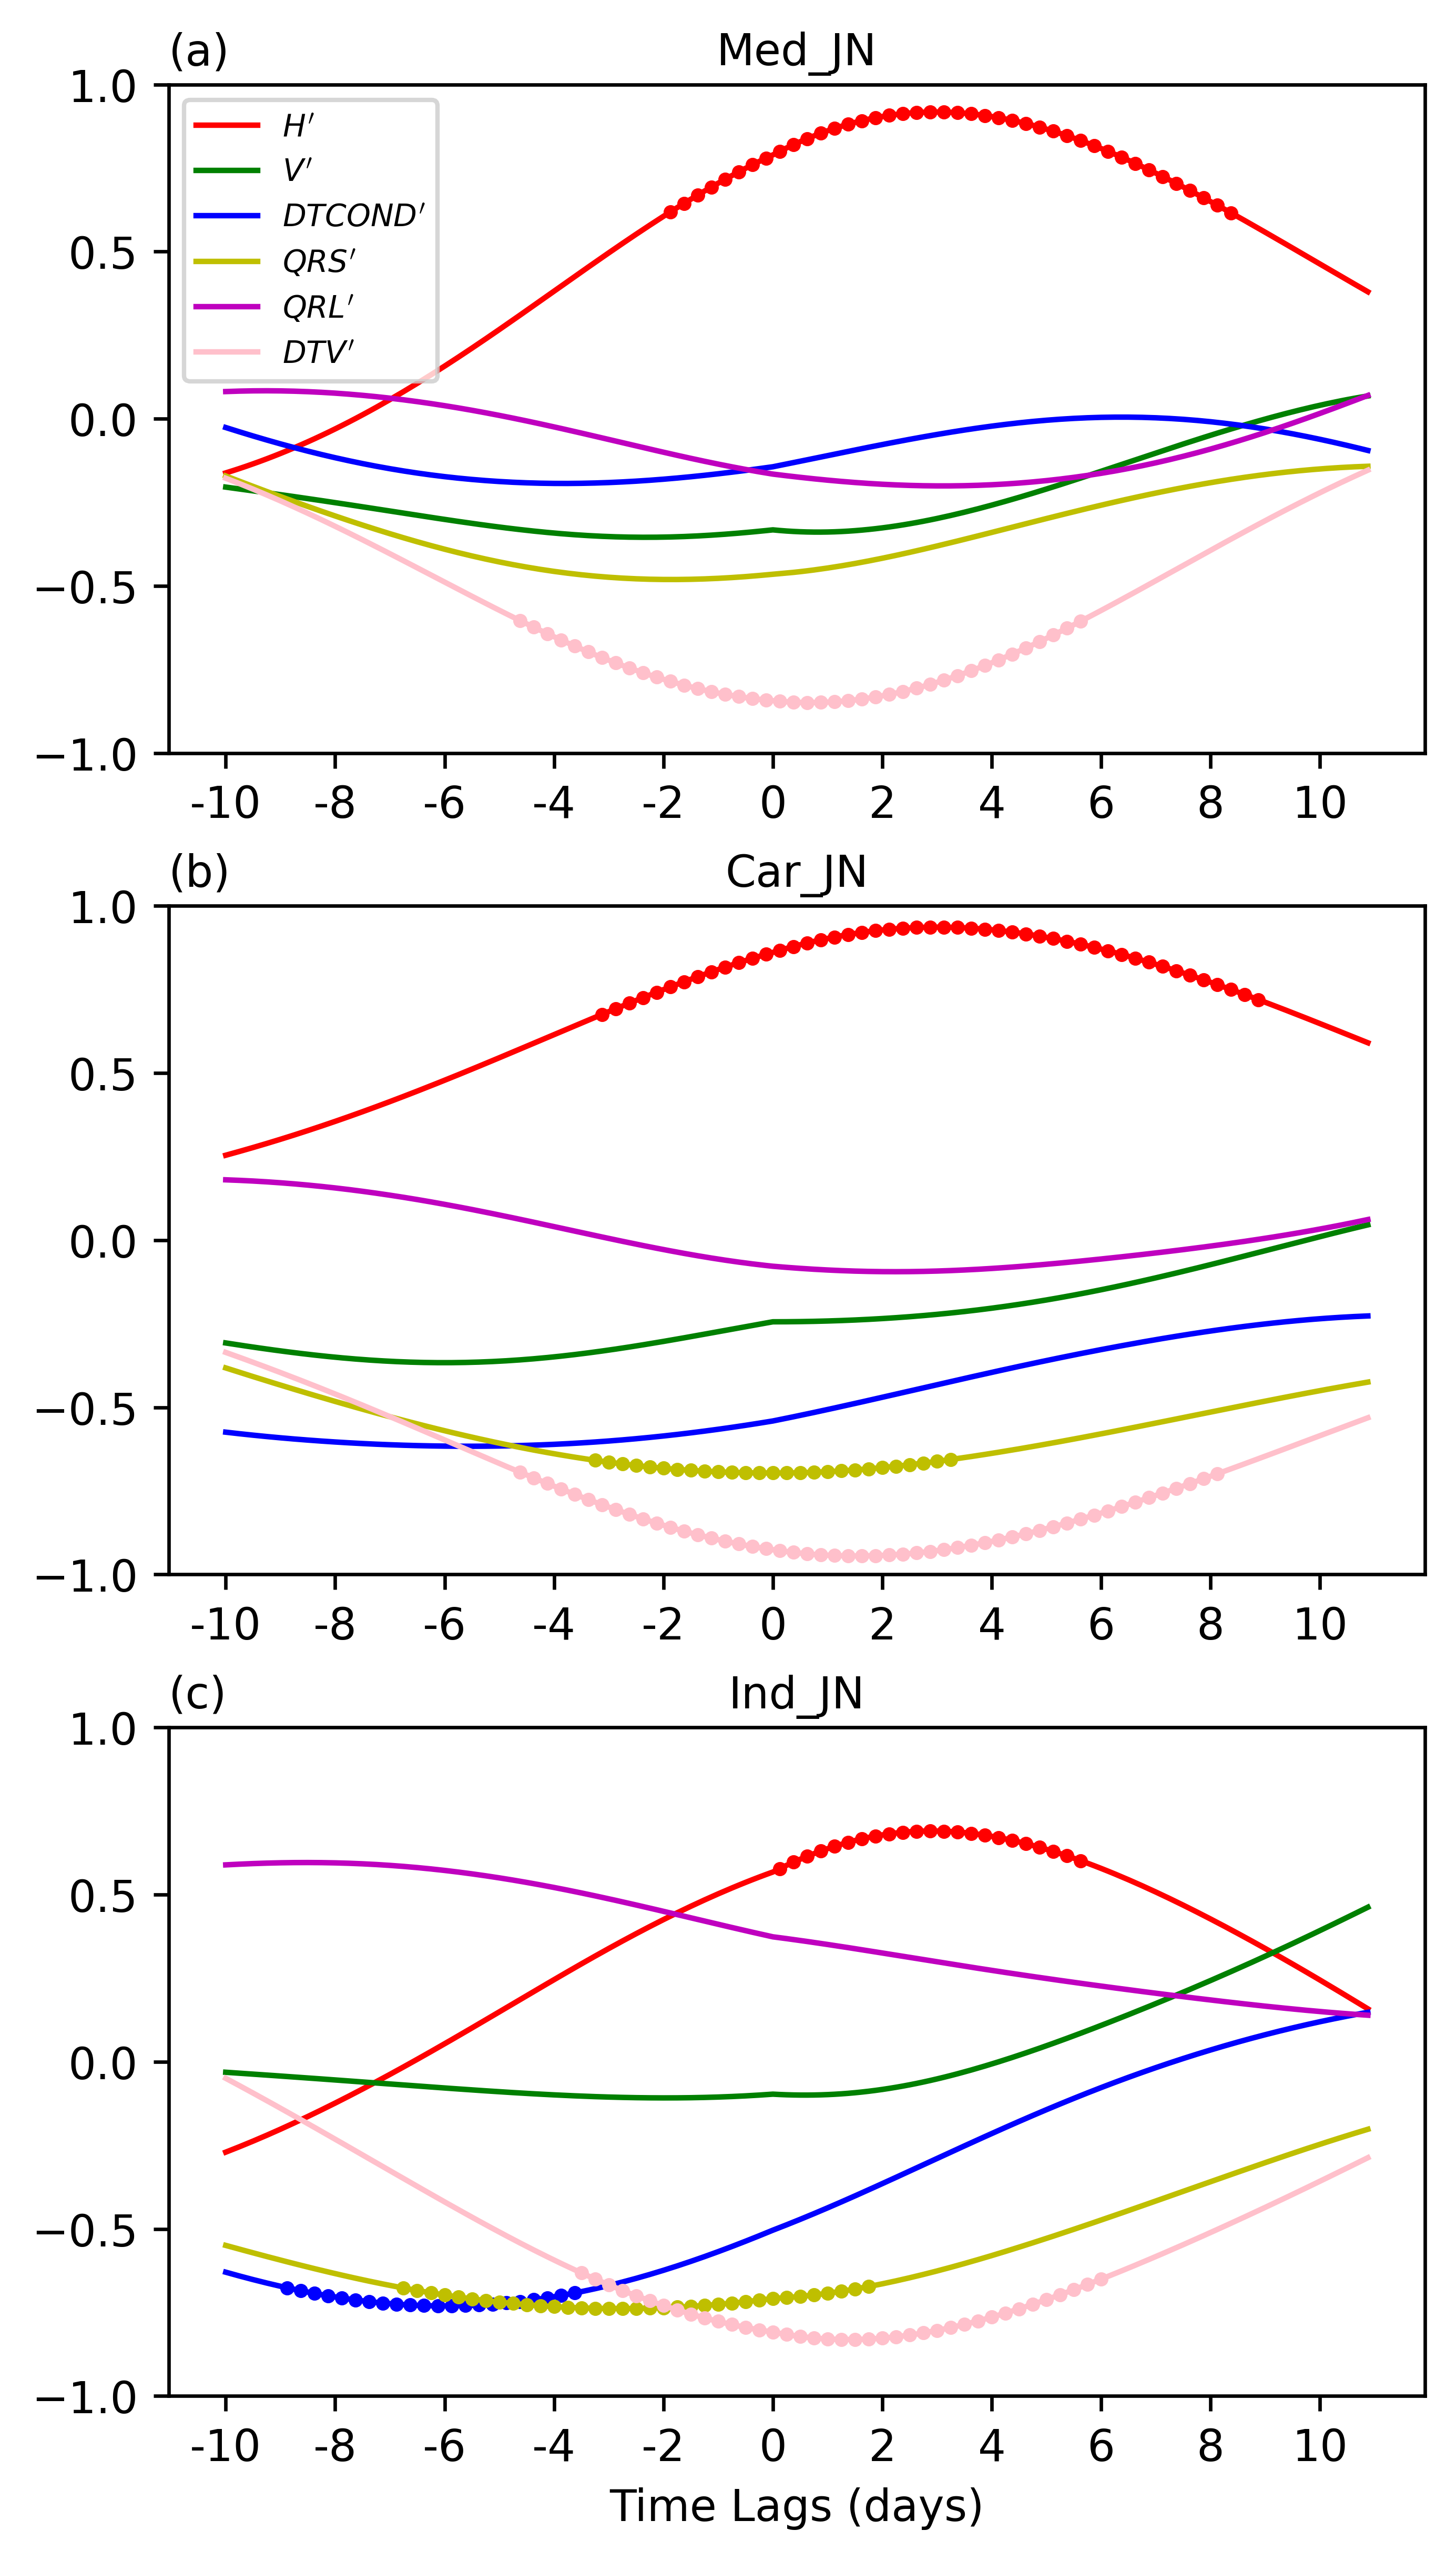

In [21]:
fig = plt.figure(figsize=(4.5,8),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=3)
dot_size=5
linewidth=1.25
fontsize=10
ax = fig.add_subplot(grid[0, 0])
lags = np.arange(-80, 88)
var=r_H_Med.to_numpy()
ax.plot(lags,var,color='r',linewidth=linewidth,label=r'$H^{\prime}$')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_H_Med < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='r',zorder=2)

var=r_V_Med.to_numpy()
ax.plot(lags,var,color='g',linewidth=linewidth,label=r'$V^{\prime}$')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_V_Med < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='g',zorder=2)

var=r_DTCOND_Med.to_numpy()
ax.plot(lags,var,color='b',linewidth=linewidth,label=r'$DTCOND^{\prime}$')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_DTCOND_Med < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='b',zorder=2)

var=r_QRS_Med.to_numpy()
ax.plot(lags,var,color='y',linewidth=linewidth,label=r'$QRS^{\prime}$')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_QRS_Med < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='y',zorder=2)

var=r_QRL_Med.to_numpy()
ax.plot(lags,var,color='m',linewidth=linewidth,label=r'$QRL^{\prime}$')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_QRL_Med < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='m',zorder=2)

var=r_DTV_Med.to_numpy()
ax.plot(lags,var,color='pink',linewidth=linewidth,label=r'$DTV^{\prime}$')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_DTV_Med < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='pink',zorder=2)

ax.legend(loc='best',fontsize=7)
max_lag=80
start_index=-max_lag
step_index =16
end_index=max_lag
xticks = np.arange(start_index, end_index+step_index, step_index)
ax.set_xticks(xticks)
# Label in days
xtick_labels = [f"{int(x/8)}" for x in xticks]
ax.set_xticklabels(xtick_labels)
# fontsize=
ax.set_title('Med_JN',fontsize=fontsize)
ax.set_title('(a)',pad=4.5,loc='left',fontsize=fontsize)
# ax.set_xlabel('Day')
ax.set_ylim([-1,1])

ax = fig.add_subplot(grid[1, 0])
lags = np.arange(-80, 88)
var=r_H_Car.to_numpy()
ax.plot(lags,var,color='r',linewidth=linewidth,label='H')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_H_Car < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='r',zorder=2)

var=r_V_Car.to_numpy()
ax.plot(lags,var,color='g',linewidth=linewidth,label='V')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_V_Car < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='g',zorder=2)

var=r_DTCOND_Car.to_numpy()
ax.plot(lags,var,color='b',linewidth=linewidth,label='DTCOND')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_DTCOND_Car < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='b',zorder=2)

var=r_QRS_Car.to_numpy()
ax.plot(lags,var,color='y',linewidth=linewidth,label='QRS')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_QRS_Car < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='y',zorder=2)

var=r_QRL_Car.to_numpy()
ax.plot(lags,var,color='m',linewidth=linewidth,label='QRL')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_QRL_Car < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='m',zorder=2)

var=r_DTV_Car.to_numpy()
ax.plot(lags,var,color='pink',linewidth=linewidth,label='DTV')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_DTV_Car < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='pink',zorder=2)

# ax.legend(loc='best',fontsize=8)
max_lag=80
start_index=-max_lag
step_index =16
end_index=max_lag
xticks = np.arange(start_index, end_index+step_index, step_index)
ax.set_xticks(xticks)
# Label in days
xtick_labels = [f"{int(x/8)}" for x in xticks]
ax.set_xticklabels(xtick_labels)
# fontsize=
ax.set_title('Car_JN',fontsize=fontsize)
ax.set_title('(b)',pad=4.5,loc='left',fontsize=fontsize)
# ax.set_xlabel('Day')
ax.set_ylim([-1,1])

ax = fig.add_subplot(grid[2, 0])
lags = np.arange(-80, 88)
var=r_H_Ind.to_numpy()
ax.plot(lags,var,color='r',linewidth=linewidth,label='H')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_H_Ind < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='r',zorder=2)

var=r_V_Ind.to_numpy()
ax.plot(lags,var,color='g',linewidth=linewidth,label='V')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_V_Ind < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='g',zorder=2)

var=r_DTCOND_Ind.to_numpy()
ax.plot(lags,var,color='b',linewidth=linewidth,label='DTCOND')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_DTCOND_Ind < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='b',zorder=2)

var=r_QRS_Ind.to_numpy()
ax.plot(lags,var,color='y',linewidth=linewidth,label='QRS')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_QRS_Ind < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='y',zorder=2)

var=r_QRL_Ind.to_numpy()
ax.plot(lags,var,color='m',linewidth=linewidth,label='QRL')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_QRL_Ind < 0.05
ax.scatter(lags[sig_mask],  var[sig_mask], s=dot_size, color='m',zorder=2)

var=r_DTV_Ind.to_numpy()
ax.plot(lags,var,color='pink',linewidth=linewidth,label='DTV')
# 2️⃣ Highlight significant points (p < 0.01)
sig_mask = p_DTV_Ind < 0.05
ax.scatter(lags[sig_mask][::2],  var[sig_mask][::2], s=dot_size, color='pink',zorder=2)

# ax.legend(loc='best',fontsize=8)
max_lag=80
start_index=-max_lag
step_index =16
end_index=max_lag
xticks = np.arange(start_index, end_index+step_index, step_index)
ax.set_xticks(xticks)
# Label in days
xtick_labels = [f"{int(x/8)}" for x in xticks]
ax.set_xticklabels(xtick_labels)
# fontsize=
ax.set_title('Ind_JN',fontsize=fontsize)
ax.set_title('(c)',pad=4.5,loc='left',fontsize=fontsize)
ax.set_xlabel('Time Lags (days)',fontsize=fontsize)
ax.set_ylim([-1,1])

In [15]:
x=lags[sig_mask][::8]
x

array([-28, -20, -12,  -4,   4,  12,  20,  28,  36,  44])